# Zamana Bağlı Veri Anazlizi

In [2]:
#pip install statsmodels

In [3]:
import pandas as pd
from datetime import date, timedelta, time  
import datetime      
import matplotlib.pyplot as plt      
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.arima_model import ARIMA

import statsmodels.api as sm


In [4]:
df = pd.read_csv("adidas-quarterly-sales.csv")

In [5]:
df.head()

,Time Period,Revenue
0,2000Q1,1517
1,2000Q2,1248
2,2000Q3,1677
3,2000Q4,1393
4,2001Q1,1558


In [6]:
#pip install plotly

In [7]:
#pip install nbformat>=4.2.0

In [8]:
import plotly.express as px
import numpy as np

In [9]:
px.line(df, x="Time Period", y="Revenue")

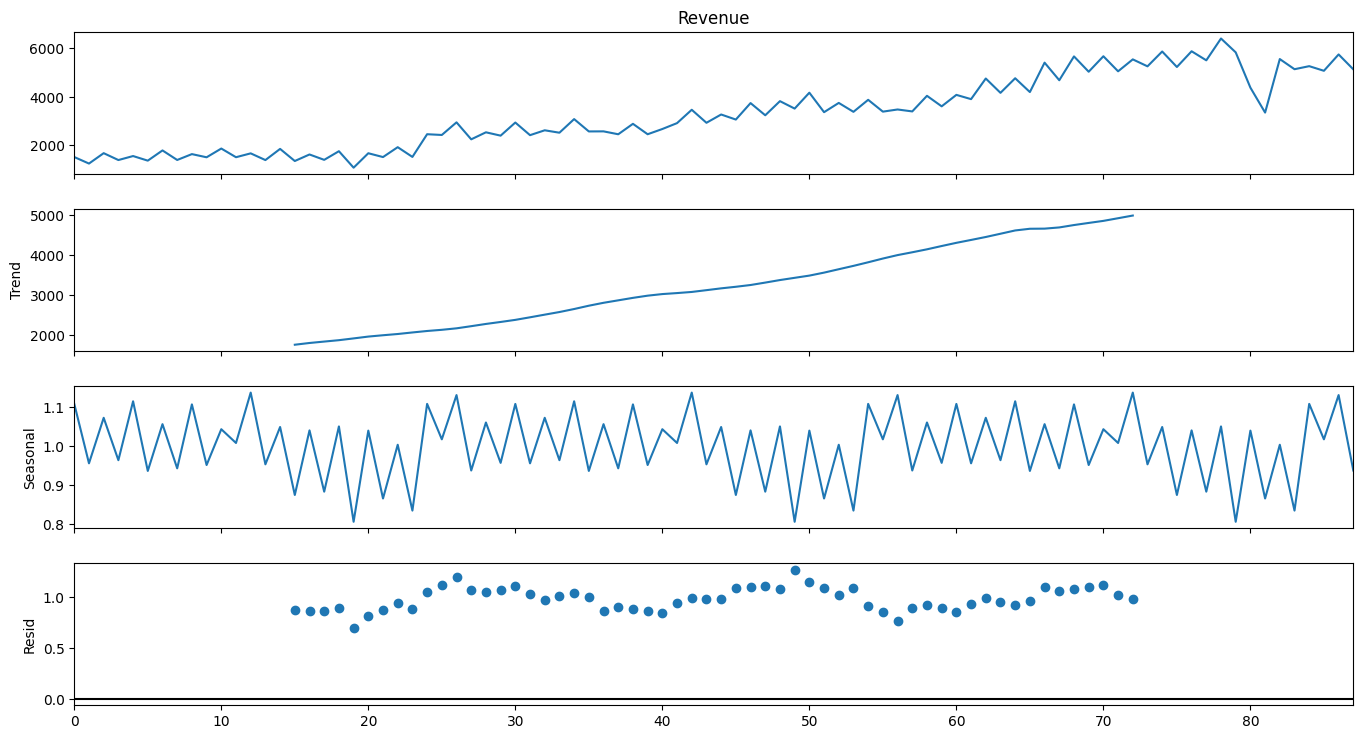

In [10]:
result = seasonal_decompose(df["Revenue"], model="multiplicative", period=30)
figure = result.plot()
,
figure.set_size_inches(15, 8)

In [11]:
model = sm.tsa.statespace.SARIMAX(df["Revenue"])
result = model.fit()

In [12]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Revenue   No. Observations:                   88
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -685.939
Date:                Tue, 09 Jun 2026   AIC                           1375.877
Time:                        19:05:29   BIC                           1380.832
Sample:                             0   HQIC                          1377.874
                                 - 88                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9878      0.014     68.840      0.000       0.960       1.016
sigma2      3.324e+05   4.14e+04      8.028      0.000    2.51e+05    4.14e+05
===================================================================================
Ljung-Box (L1) (Q):                  33.98   Jarque-Bera (JB):                 7.84
Prob(Q):                              0.00   Prob(JB):                         0.02
Heteroskedasticity (H):               3.78   Skew:                             0.50
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.07
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
predictions = result.predict(len(df),len(df) + 7)

In [14]:
predictions

88    5074.368262
89    5012.500147
90    4951.386345
91    4891.017660
92    4831.385007
93    4772.479412
94    4714.292010
95    4656.814046
Name: predicted_mean, dtype: float64

<Axes: >

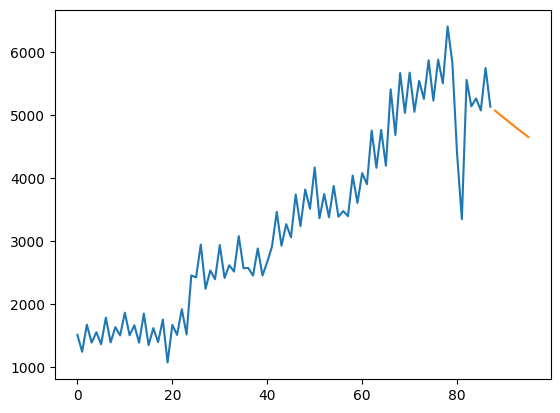

In [15]:
df['Revenue'].plot()
predictions.plot()